# Seismic-only Unimodal Model

### 구글 드라이브 마운트

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 라이브러리 import

In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
from tqdm.notebook import tqdm
import copy
import random
from torch.utils.checkpoint import checkpoint
from torch.cuda.amp import autocast, GradScaler
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point

### 데이터셋 로드

In [3]:
# Vs30 Lookup 생성
def build_vs30_lookup_integrated(meta_csv_dict, shp_path,
                                 correction_mode="arv", vs30_ref=760.0,
                                 fallback_mode="median"):
    """
    4개 지진 meta CSV를 통합하여 seismic_station → vs30_feat(정규화 스칼라) 반환.
    동일 관측소가 여러 지진에 등장해도 중복 제거 후 처리.
    """
    all_meta = []
    for event, csv_path in meta_csv_dict.items():
        df = pd.read_csv(csv_path)
        df["seismic_station"] = df["seismic_station"].astype(str).str.strip().str.upper()
        df = df[["seismic_station", "seismic_lat", "seismic_lon"]].drop_duplicates("seismic_station")
        all_meta.append(df)
    meta_df = pd.concat(all_meta, ignore_index=True).drop_duplicates("seismic_station")

    lats, lons = meta_df["seismic_lat"].values, meta_df["seismic_lon"].values
    margin = 0.5
    bbox = (lons.min()-margin, lats.min()-margin, lons.max()+margin, lats.max()+margin)

    vs30_gdf = gpd.read_file(shp_path, bbox=bbox).to_crs("EPSG:4326")
    pts_gdf  = gpd.GeoDataFrame(
        meta_df.copy(),
        geometry=[Point(lo, la) for lo, la in zip(lons, lats)],
        crs="EPSG:4326"
    )
    joined = gpd.sjoin(pts_gdf, vs30_gdf[["AVS", "ARV", "geometry"]],
                       how="left", predicate="within")
    joined = joined.drop_duplicates(subset=["seismic_station"])
    meta_df = meta_df.copy()
    meta_df["vs30_avs"] = joined["AVS"].values
    meta_df["vs30_arv"] = joined["ARV"].values

    def get_amp(row):
        if correction_mode == "arv":
            v = row["vs30_arv"]
            return float(v) if pd.notna(v) and v > 0 else np.nan
        else:
            v = row["vs30_avs"]
            if pd.isna(v) or v <= 0: return np.nan
            return float(np.exp(-0.84 * np.log(np.clip(v, 100., 2000.) / vs30_ref)))

    meta_df["amp_factor"] = meta_df.apply(get_amp, axis=1)
    valid = meta_df["amp_factor"].dropna()
    fallback = float(valid.median()) if fallback_mode == "median" else float(fallback_mode)
    meta_df["amp_factor"] = meta_df["amp_factor"].fillna(fallback)

    # log 변환 후 Z-score 정규화
    log_amps = np.log(meta_df["amp_factor"].clip(lower=1e-3))
    mu, sigma = log_amps.mean(), log_amps.std()
    sigma = sigma if sigma > 1e-8 else 1.0
    meta_df["vs30_feat"] = (log_amps - mu) / sigma

    lookup = dict(zip(meta_df["seismic_station"], meta_df["vs30_feat"]))
    print(f"[Vs30] 통합 lookup: {len(lookup)}개 관측소 | fallback={fallback:.4f} | "
          f"log_amp μ={mu:.4f} σ={sigma:.4f}")
    return lookup

In [4]:
all_pgv_path = "/content/drive/MyDrive/TriAI/그로쓰/Data/processed/multimodal/추가 실험/통합/pgv_all.csv"
all_seismic_path = "/content/drive/MyDrive/TriAI/그로쓰/Data/processed/multimodal/추가 실험/통합/seismic_all.npz"

META_CSV = {
    "tohoku":   f"/content/drive/MyDrive/TriAI/그로쓰/Data/csv/station_pairs/tohoku/tohoku_station_pairs_ver_25km.csv",
    "noto":     f"/content/drive/MyDrive/TriAI/그로쓰/Data/csv/station_pairs/noto/noto_station_pairs_ver_25km.csv",
    "hokkaido": f"/content/drive/MyDrive/TriAI/그로쓰/Data/csv/station_pairs/hokkaido/hokkaido_station_pairs_ver_25km.csv",
    "kumamoto": f"/content/drive/MyDrive/TriAI/그로쓰/Data/csv/station_pairs/kumamoto/kumamoto_station_pairs_ver_25km.csv",
}

VS30_SHP = f"/content/drive/MyDrive/TriAI/그로쓰/Data/postprocessing/vs30 데이터/Z-V4-JAPAN-AMP-VS400_M250-SHAPE.shp"

SEED          = 42
BATCH_SIZE    = 16
NUM_EPOCHS    = 100
LEARNING_RATE = 3e-4
PATIENCE      = 40

In [5]:
class SeismicDataset(Dataset):
    def __init__(self, all_pgv_path, all_seismic_path,
                 target_events, is_train=True,
                 y_mean=None, y_std=None, vs30_dict=None):
        seismic_data = np.load(all_seismic_path, allow_pickle=True)
        self.seismic = seismic_data['data']
        self.seismic_station = seismic_data['station_names']

        # 지진명 column 저장
        self.events = seismic_data['name']

        pgv_data = pd.read_csv(all_pgv_path)

        self.pgv_dict = dict(zip(
            pgv_data['seismic_station'].astype(str).str.strip(),
            pgv_data['pgv']
        ))
        self.is_train = is_train
        self.vs30_dict = vs30_dict if vs30_dict is not None else {}

        target_set = set(target_events)

        self.valid_indices = [
            i for i in range(len(self.seismic))
            if (str(self.events[i]).strip() in target_set and
                str(self.seismic_station[i]).strip().strip("[]\'") in self.pgv_dict)
        ]
        print(f"[Dataset] events={target_events} | 유효 샘플: {len(self.valid_indices)}")

        assert y_mean is not None and y_std is not None, \
            "y_mean, y_std는 compute_combined_stats()로 미리 계산해서 전달하세요."
        self.y_mean = y_mean
        self.y_std  = y_std

        self.sample_events = [
            str(self.events[i]).strip() for i in self.valid_indices
        ]

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        idx = self.valid_indices[idx]
        seismic = np.copy(self.seismic[idx]) # (W, T_s, C)
        seismic_station = str(self.seismic_station[idx]).strip().strip("[]\'")

        raw_pgv   = self.pgv_dict.get(seismic_station, 0.0)
        pgv_label = (np.log1p(raw_pgv) - self.y_mean) / self.y_std

        # Get vs30 feature from the lookup dictionary
        vs30_feat = self.vs30_dict.get(seismic_station, 0.0)

        # 증강 (정규화 전)
        if self.is_train:
            if random.random() < 0.3:
                seismic += np.random.normal(0, 0.05, seismic.shape).astype(np.float32)
            if random.random() < 0.2:
                ch = random.randint(0, 2)
                seismic[:, :, ch] = 0

        # 정규화: axis=1 (시간축)
        seismic = seismic.astype(np.float32)
        s_mean = seismic.mean(axis=1, keepdims=True)
        s_std  = seismic.std(axis=1, keepdims=True).clip(min=1e-8)
        seismic = (seismic - s_mean) / s_std

        # (W, T_s, C) -> (W, C, T_s)
        x_tensor = torch.tensor(seismic.transpose(0, 2, 1), dtype=torch.float32)
        y_tensor = torch.tensor([pgv_label], dtype=torch.float32)
        vs30_tensor = torch.tensor([vs30_feat], dtype=torch.float32) # Convert vs30_feat to a tensor

        return x_tensor, y_tensor, seismic_station, vs30_tensor

def compute_combined_stats(pgv_csv, train_events):
    """
    train_events에 속하는 샘플만으로 y_mean/y_std 계산.
    test 이벤트의 PGV는 정규화 통계에 포함하지 않음.
    """
    df = pd.read_csv(pgv_csv)
    train_df = df[df['name'].isin(train_events)]
    log_pgv  = np.log1p(train_df['pgv'].values.astype(np.float32))
    y_mean   = float(np.mean(log_pgv))
    y_std    = float(np.std(log_pgv))
    y_std    = y_std if y_std > 1e-8 else 1.0
    print(f"[Combined Stats] train_events={train_events} | "
          f"y_mean={y_mean:.6f}, y_std={y_std:.6f} (n={len(log_pgv)})")
    return y_mean, y_std

### Seismic model

In [6]:
class ResNetBlock(nn.Module):
    def __init__(self, filters, kernel_size, drop_rate):
        super().__init__()
        pad = kernel_size // 2
        self.bn1   = nn.BatchNorm1d(filters)
        self.drop1 = nn.Dropout1d(drop_rate)
        self.conv1 = nn.Conv1d(filters, filters, kernel_size, padding=pad)
        self.bn2   = nn.BatchNorm1d(filters)
        self.drop2 = nn.Dropout1d(drop_rate)
        self.conv2 = nn.Conv1d(filters, filters, kernel_size, padding=pad)

    def forward(self, x):
        out = self.conv1(self.drop1(F.relu(self.bn1(x))))
        out = self.conv2(self.drop2(F.relu(self.bn2(out))))
        return out + x


class BiLSTMBlock(nn.Module):
    def __init__(self, in_channels, hidden, drop_rate):
        super().__init__()
        self.drop_rate = drop_rate
        self.bilstm = nn.LSTM(in_channels, hidden, batch_first=True, bidirectional=True)
        self.nin    = nn.Conv1d(hidden * 2, hidden, 1)
        self.bn     = nn.BatchNorm1d(hidden)

    def forward(self, x):           # (B, C, T)
        x = F.dropout(x.permute(0, 2, 1), p=self.drop_rate, training=self.training)
        out, _ = self.bilstm(x)     # (B, T, 2H)
        out = self.nin(out.permute(0, 2, 1))
        return self.bn(out)


class SeismicEncoder(nn.Module):
    """
    Input : (B, 3, T_s)  — 100Hz 원본
    Output: (B, T_s', output_dim)
    MaxPool 3회 (1/8) + avg_pool 4 = 총 1/32 압축
    """
    def __init__(self, in_ch=3, drop_rate=0.2, output_dim=128):
        super().__init__()
        # (out_ch, kernel, pool여부)
        cfg = [
            (8,  11, True),
            (16,  9, True),
            (16,  7, True),
            (32,  7, False),
            (32,  5, False),
            (96,  5, False),
            (96,  3, False),
        ]
        self.convs = nn.ModuleList()
        c = in_ch
        for out_c, k, pool in cfg:
            layers = [nn.Conv1d(c, out_c, k, padding=k//2), nn.ReLU()]
            if pool:
                layers.append(nn.MaxPool1d(2))
            self.convs.append(nn.Sequential(*layers))
            c = out_c

        self.res_blocks = nn.ModuleList(
            [ResNetBlock(96, 3, drop_rate) for _ in range(5)]
        )

        lstm_hidden = 64
        self.bilstm_blocks = nn.ModuleList()
        lc = 96
        for _ in range(2):
            self.bilstm_blocks.append(BiLSTMBlock(lc, lstm_hidden, drop_rate))
            lc = lstm_hidden

        enc_layer = nn.TransformerEncoderLayer(
            d_model=lstm_hidden, nhead=4, dim_feedforward=256,
            dropout=drop_rate, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=2)
        self.proj = nn.Linear(lstm_hidden, output_dim)

    def forward(self, x):
        for conv in self.convs:
            x = checkpoint(conv, x, use_reentrant=False)
        for res in self.res_blocks:
            x = checkpoint(res, x, use_reentrant=False)
        for bilstm in self.bilstm_blocks:
            x = checkpoint(bilstm, x, use_reentrant=False)
        x = F.avg_pool1d(x, kernel_size=4, stride=4)
        x = self.transformer(x.permute(0, 2, 1))
        return self.proj(x)          # (B, T_s', output_dim)

class Decoder(nn.Module):
    def __init__(self, input_dim=128, hidden_dim=64, output_dim=1, dropout=0.3):
        super().__init__()
        self.attn_pool = nn.Linear(input_dim, 1)
        self.mlp = nn.Sequential(
            nn.Linear(input_dim + 1, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
        )
        self.reg = nn.Linear(hidden_dim // 2, output_dim)

    def forward(self, x, vs30):
        w   = torch.softmax(self.attn_pool(x).squeeze(-1), dim=1).unsqueeze(-1)
        ctx = (x * w).sum(dim=1)    # (B, D)
        ctx = torch.cat([ctx, vs30], dim=1)
        return self.reg(self.mlp(ctx))

In [7]:
class SeismicOnlyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = SeismicEncoder(output_dim=128)
        self.decoder = Decoder(input_dim=128, hidden_dim=64)

    def forward(self, x_s, vs30):
        B, W, C, T_s = x_s.shape
        s_flat = x_s.view(B * W, C, T_s)
        f_s = self.encoder(s_flat)          # (BW, T_s', 128)
        _, T_out, D = f_s.shape
        f_s = f_s.view(B, W * T_out, D)    # (B, W*T_out, 128)
        return self.decoder(f_s, vs30)

### 학습 유틸

In [8]:
def get_cosine_warmup_scheduler(optimizer, warmup_epochs, total_epochs, min_lr_ratio=0.05):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
        cosine = 0.5 * (1.0 + np.cos(np.pi * progress))
        return min_lr_ratio + (1.0 - min_lr_ratio) * cosine
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


class HuberMSELoss(nn.Module):
    def __init__(self, alpha=0.5, delta=1.0):
        super().__init__()
        self.alpha = alpha
        self.huber = nn.HuberLoss(delta=delta)
        self.mse   = nn.MSELoss()

    def forward(self, pred, target):
        return self.alpha * self.mse(pred, target) + (1 - self.alpha) * self.huber(pred, target)

### 시각화 유틸

In [9]:
def summarize(metric, experiment_name):
    best_epoch = metric['val_rmse'].index(min(metric['val_rmse'])) + 1
    print(f"\n====================================================================")
    print(f"[{experiment_name}] 학습 결과 요약")
    print(f"====================================================================")
    print(f"  Best Val RMSE    : {min(metric['val_rmse']):.2f}  (Epoch {best_epoch})")
    print(f"  Val Loss 스파이크: {sum(1 for v in metric['val_loss'] if v > 10)}회")
    print(f"  최종 Train Loss  : {metric['train_loss'][-1]:.4f}")
    print(f"  최종 Val Loss    : {metric['val_loss'][-1]:.4f}")
    if 'test_loss' in metric and 'test_rmse' in metric:
        print(f"--------------------------------------------------------------------")
        print(f"  최종 Test Loss   : {metric['test_loss']:.4f}")
        print(f"  최종 Test RMSE   : {metric['test_rmse']:.2f}")
    print(f"====================================================================")


def plot_best_model_predictions(model, loader, device, title_name, y_mean, y_std):
    model.eval()
    actuals, predictions = [], []
    with torch.no_grad():
        for x_s, targets, _, vs30 in loader:
            outputs = model(x_s.to(device), vs30.to(device))
            actuals.extend(targets.numpy().flatten())
            predictions.extend(outputs.cpu().numpy().flatten())

    act_orig  = np.expm1(np.array(actuals)      * y_std + y_mean)
    pred_orig = np.expm1(np.array(predictions)  * y_std + y_mean)

    plt.figure(figsize=(10, 10))
    plt.scatter(act_orig, pred_orig, alpha=0.5, color='dodgerblue', edgecolor='k', s=50)
    max_val = 100
    plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
    plt.plot([0, max_val], [10, max_val+10], color='gray', linestyle=':', alpha=0.7, label='+10 Error')
    plt.plot([0, max_val], [-10, max_val-10], color='gray', linestyle=':', alpha=0.7, label='-10 Error')
    plt.title(f'[{title_name}] Best Model: Actual vs Predicted', fontsize=16, fontweight='bold')
    plt.xlabel('Actual PGV', fontsize=14); plt.ylabel('Predicted PGV', fontsize=14)
    plt.xlim(0, max_val); plt.ylim(0, max_val)
    plt.grid(True, linestyle='--', alpha=0.6); plt.legend(fontsize=12)
    plt.tight_layout(); plt.show()

### Training

In [10]:
def main(test_event="noto"):
    os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    all_event_names = list(META_CSV.keys()) # Get all event names from META_CSV
    train_events_list = [event for event in all_event_names if event != test_event] # Determine train_events

    y_mean, y_std = compute_combined_stats(all_pgv_path, train_events_list) # Use all_pgv_path and train_events_list

    train_dataset    = SeismicDataset(all_pgv_path, all_seismic_path, target_events=train_events_list,
                                      is_train=True, y_mean=y_mean, y_std=y_std, vs30_dict=vs30_lookup)
    val_test_dataset = SeismicDataset(all_pgv_path, all_seismic_path, target_events=[test_event],
                                      is_train=False, y_mean=y_mean, y_std=y_std, vs30_dict=vs30_lookup)
    print(f">> Train: {test_event} 제외 나머지 세 지진 / Val+Test: {test_event}")

    n_val  = int(len(val_test_dataset) * 0.2)
    n_test = len(val_test_dataset) - n_val
    val_dataset, test_dataset = random_split(
        val_test_dataset, [n_val, n_test],
        generator=torch.Generator().manual_seed(SEED)
    )

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True,  num_workers=2)
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    model     = SeismicOnlyModel().to(device)
    criterion = HuberMSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-3)
    scheduler = get_cosine_warmup_scheduler(optimizer, warmup_epochs=5, total_epochs=NUM_EPOCHS)
    scaler    = GradScaler()

    ym, ys = train_dataset.y_mean, train_dataset.y_std
    best_val_rmse    = float('inf')
    best_weights     = None
    patience_counter = 0
    metrics = {
        'epoch': [], 'train_loss': [], 'val_loss': [],
        'val_rmse': [], 'lr': [], 'y_mean': ym, 'y_std': ys
    }

    print("============================== Train ==============================")
    for epoch in range(NUM_EPOCHS):
        model.train()
        train_loss = 0.0
        for x_s, y, _, vs30 in train_loader:
            x_s, y, vs30 = x_s.to(device), y.to(device), vs30.to(device)
            optimizer.zero_grad()
            with autocast():
                loss = criterion(model(x_s, vs30), y)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()
        avg_train = train_loss / len(train_loader)

        model.eval()
        val_loss, val_preds, val_tgts = 0.0, [], []
        with torch.no_grad():
            for x_s, y, _, vs30 in val_loader:
                x_s, y, vs30 = (x_s.to(device), y.to(device), vs30.to(device))
                with autocast():
                    out = model(x_s, vs30)
                val_loss += criterion(out, y).item()
                val_preds.extend(out.cpu().numpy().flatten())
                val_tgts.extend(y.cpu().numpy().flatten())
        avg_val = val_loss / len(val_loader)

        scheduler.step()
        cur_lr = optimizer.param_groups[0]['lr']

        vp = np.expm1(np.array(val_preds) * ys + ym)
        vt = np.expm1(np.array(val_tgts)  * ys + ym)
        val_rmse = float(np.sqrt(np.mean((vp - vt) ** 2)))

        metrics['epoch'].append(epoch + 1)
        metrics['train_loss'].append(avg_train)
        metrics['val_loss'].append(avg_val)
        metrics['val_rmse'].append(val_rmse)
        metrics['lr'].append(cur_lr)

        if val_rmse < best_val_rmse:
            best_val_rmse    = val_rmse
            best_weights     = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print(f"  [Patience {PATIENCE}] Best model 가중치 복원 후 계속 학습")
            model.load_state_dict(best_weights)
            patience_counter = 0

        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] LR: {cur_lr:.6f} | "
              f"Train: {avg_train:.4f} | Val: {avg_val:.4f} (RMSE: {val_rmse:.2f})")

    model.load_state_dict(best_weights)
    torch.save(best_weights, f'best_seismic_test_{test_event}_model.pth')

    print("\n=============================== Test ==============================")
    model.eval()
    test_loss, test_preds, test_tgts, test_stations = 0.0, [], [], []
    with torch.no_grad():
        for x_s, y, stations, vs30 in test_loader:
            x_s, y, vs30 = x_s.to(device), y.to(device), vs30.to(device)
            with autocast():
                out = model(x_s, vs30)
            test_loss += criterion(out, y).item()
            test_preds.extend(out.cpu().numpy().flatten())
            test_tgts.extend(y.cpu().numpy().flatten())
            test_stations.extend(stations)

    tp = np.expm1(np.array(test_preds) * ys + ym)
    tt = np.expm1(np.array(test_tgts)  * ys + ym)
    test_rmse = float(np.sqrt(np.mean((tp - tt) ** 2)))

    metrics['test_loss'] = test_loss / len(test_loader)
    metrics['test_rmse'] = test_rmse

    print(f"Final Test Loss: {test_loss:.4f} | Test RMSE: {test_rmse:.2f}")

    return model, metrics, test_loader

# [실험 1] Train: Tohoku, Kumamoto, Hokkaido / Test: Noto

=== Vs30 Lookup 빌드 ===
[Vs30] 통합 lookup: 280개 관측소 | fallback=0.9533 | log_amp μ=-0.0317 σ=0.2825
===== [실험 1] Train: Tohoku, Kumamoto, Hokkaido / Test: Noto ====

Device: cuda
[Combined Stats] train_events=['tohoku', 'hokkaido', 'kumamoto'] | y_mean=2.110529, y_std=0.960822 (n=394)
[Dataset] events=['tohoku', 'hokkaido', 'kumamoto'] | 유효 샘플: 394
[Dataset] events=['noto'] | 유효 샘플: 176
>> Train: noto 제외 나머지 세 지진 / Val+Test: noto
============================== Train ==============================


/tmp/ipykernel_963/2299933679.py:32: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()
/tmp/ipykernel_963/2299933679.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/100] LR: 0.000120 | Train: 0.7627 | Val: 1.1399 (RMSE: 13.65)


/tmp/ipykernel_963/2299933679.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [2/100] LR: 0.000180 | Train: 0.7113 | Val: 1.1284 (RMSE: 13.37)
Epoch [3/100] LR: 0.000240 | Train: 0.5755 | Val: 0.9223 (RMSE: 12.72)
Epoch [4/100] LR: 0.000300 | Train: 0.4924 | Val: 0.6061 (RMSE: 13.01)
Epoch [5/100] LR: 0.000300 | Train: 0.4426 | Val: 1.2511 (RMSE: 12.79)
Epoch [6/100] LR: 0.000300 | Train: 0.4330 | Val: 0.3946 (RMSE: 12.86)
Epoch [7/100] LR: 0.000300 | Train: 0.3969 | Val: 0.3053 (RMSE: 12.06)
Epoch [8/100] LR: 0.000299 | Train: 0.4252 | Val: 1.1106 (RMSE: 11.60)
Epoch [9/100] LR: 0.000299 | Train: 0.4151 | Val: 0.4543 (RMSE: 13.87)
Epoch [10/100] LR: 0.000298 | Train: 0.3496 | Val: 0.4418 (RMSE: 13.72)
Epoch [11/100] LR: 0.000297 | Train: 0.3402 | Val: 0.3216 (RMSE: 12.95)
Epoch [12/100] LR: 0.000296 | Train: 0.3228 | Val: 0.3290 (RMSE: 12.67)
Epoch [13/100] LR: 0.000295 | Train: 0.2875 | Val: 0.2970 (RMSE: 12.76)
Epoch [14/100] LR: 0.000294 | Train: 0.2775 | Val: 0.3687 (RMSE: 12.27)
Epoch [15/100] LR: 0.000292 | Train: 0.2768 | Val: 0.3824 (RMSE: 12.66)


/tmp/ipykernel_963/2299933679.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Final Test Loss: 3.6656 | Test RMSE: 10.96

[Train: Tohoku, Kumamoto, Hokkaido -> Test: Noto] 학습 결과 요약
  Best Val RMSE    : 8.98  (Epoch 87)
  Val Loss 스파이크: 0회
  최종 Train Loss  : 0.0995
  최종 Val Loss    : 0.2252
--------------------------------------------------------------------
  최종 Test Loss   : 0.4073
  최종 Test RMSE   : 10.96


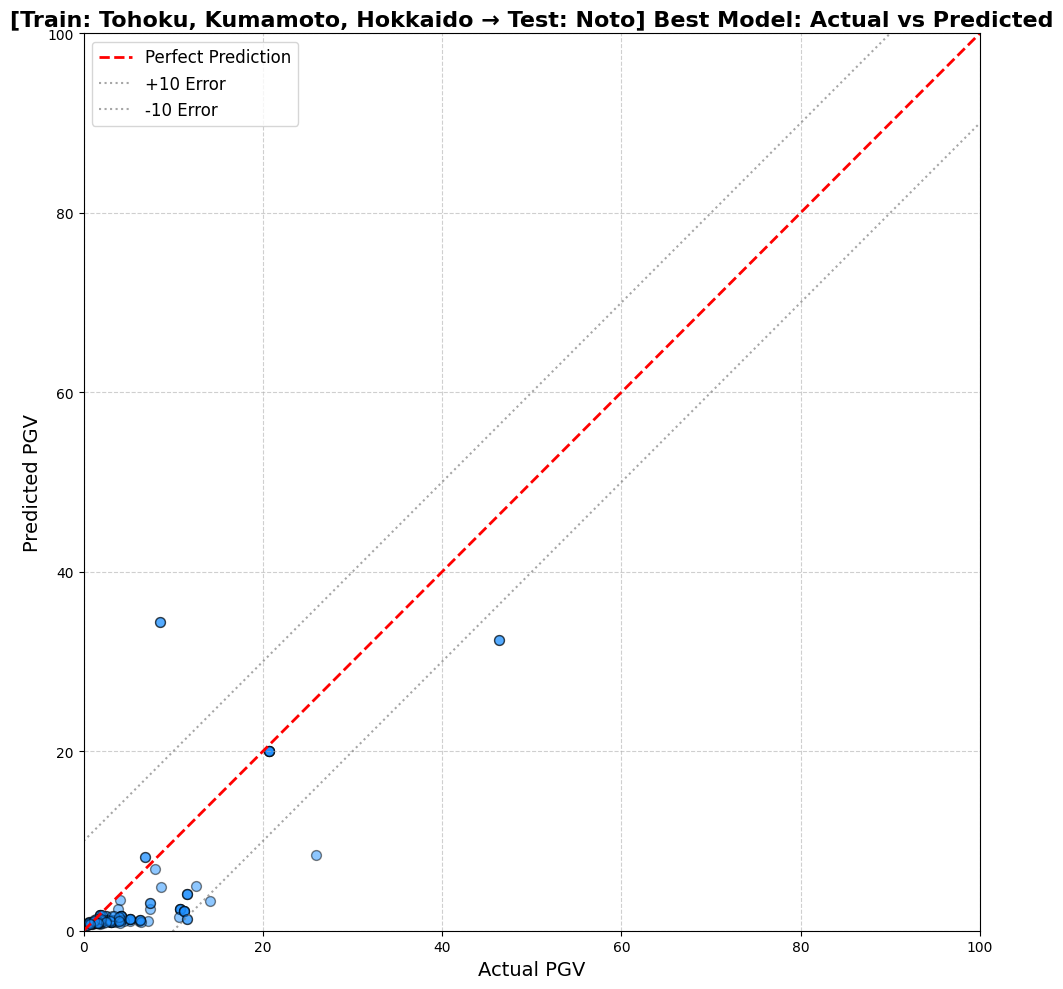

In [11]:
if __name__ == '__main__':
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print("=== Vs30 Lookup 빌드 ===")
    vs30_lookup = build_vs30_lookup_integrated(META_CSV, VS30_SHP)

    print("===== [실험 1] Train: Tohoku, Kumamoto, Hokkaido / Test: Noto ====\n")
    best_model_2n, metric_2n, test_loader_2n = main(test_event="noto")

    summarize(metric_2n, "Train: Tohoku, Kumamoto, Hokkaido -> Test: Noto")

    plot_best_model_predictions(best_model_2n, test_loader_2n, device, "Train: Tohoku, Kumamoto, Hokkaido → Test: Noto",
                                y_mean=metric_2n['y_mean'], y_std=metric_2n['y_std'])

# [실험 2] Train: Tohoku, Kumamoto, Noto / Test: Hokkaido

=== Vs30 Lookup 빌드 ===
[Vs30] 통합 lookup: 280개 관측소 | fallback=0.9533 | log_amp μ=-0.0317 σ=0.2825

===== [실험 2] Train: Tohoku, Kumamoto, Noto / Test: Hokkaido ====

Device: cuda
[Combined Stats] train_events=['tohoku', 'noto', 'kumamoto'] | y_mean=2.079253, y_std=0.942309 (n=450)
[Dataset] events=['tohoku', 'noto', 'kumamoto'] | 유효 샘플: 450
[Dataset] events=['hokkaido'] | 유효 샘플: 120
>> Train: hokkaido 제외 나머지 세 지진 / Val+Test: hokkaido
============================== Train ==============================


/tmp/ipykernel_963/2299933679.py:32: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()
/tmp/ipykernel_963/2299933679.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/100] LR: 0.000120 | Train: 0.7331 | Val: 0.8221 (RMSE: 4.82)


/tmp/ipykernel_963/2299933679.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [2/100] LR: 0.000180 | Train: 0.6698 | Val: 1.4022 (RMSE: 7.39)
Epoch [3/100] LR: 0.000240 | Train: 0.5006 | Val: 1.7168 (RMSE: 10.09)
Epoch [4/100] LR: 0.000300 | Train: 0.4787 | Val: 0.8588 (RMSE: 5.07)
Epoch [5/100] LR: 0.000300 | Train: 0.4637 | Val: 0.7216 (RMSE: 4.45)
Epoch [6/100] LR: 0.000300 | Train: 0.3881 | Val: 0.4699 (RMSE: 4.93)
Epoch [7/100] LR: 0.000300 | Train: 0.3885 | Val: 0.5413 (RMSE: 5.18)
Epoch [8/100] LR: 0.000299 | Train: 0.3274 | Val: 0.4466 (RMSE: 4.47)
Epoch [9/100] LR: 0.000299 | Train: 0.3421 | Val: 1.0027 (RMSE: 6.11)
Epoch [10/100] LR: 0.000298 | Train: 0.3281 | Val: 0.4938 (RMSE: 4.91)
Epoch [11/100] LR: 0.000297 | Train: 0.2880 | Val: 0.4124 (RMSE: 4.12)
Epoch [12/100] LR: 0.000296 | Train: 0.3243 | Val: 0.6074 (RMSE: 4.32)
Epoch [13/100] LR: 0.000295 | Train: 0.3082 | Val: 0.7873 (RMSE: 5.63)
Epoch [14/100] LR: 0.000294 | Train: 0.2657 | Val: 0.4840 (RMSE: 4.87)
Epoch [15/100] LR: 0.000292 | Train: 0.2603 | Val: 0.4851 (RMSE: 4.16)
Epoch [16/100

/tmp/ipykernel_963/2299933679.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Final Test Loss: 3.6714 | Test RMSE: 8.25

[Train: Tohoku, Kumamoto, Noto -> Test: Hokkaido] 학습 결과 요약
  Best Val RMSE    : 3.76  (Epoch 64)
  Val Loss 스파이크: 0회
  최종 Train Loss  : 0.0840
  최종 Val Loss    : 0.6976
--------------------------------------------------------------------
  최종 Test Loss   : 0.6119
  최종 Test RMSE   : 8.25


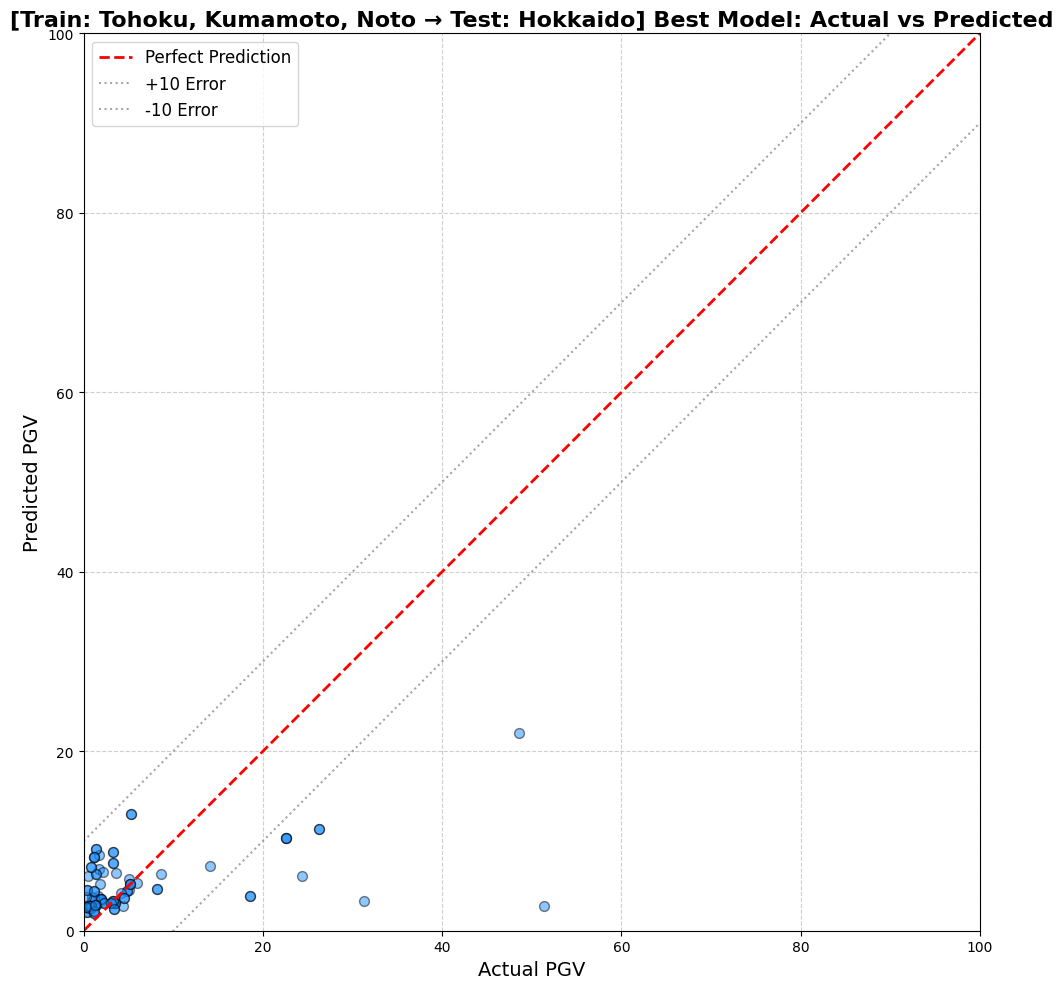

In [12]:
if __name__ == '__main__':
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print("=== Vs30 Lookup 빌드 ===")
    vs30_lookup = build_vs30_lookup_integrated(META_CSV, VS30_SHP)

    print("\n===== [실험 2] Train: Tohoku, Kumamoto, Noto / Test: Hokkaido ====\n")
    best_model_2h, metric_2h, test_loader_2h = main(test_event="hokkaido")

    summarize(metric_2h, "Train: Tohoku, Kumamoto, Noto -> Test: Hokkaido")

    plot_best_model_predictions(best_model_2h, test_loader_2h, device, "Train: Tohoku, Kumamoto, Noto → Test: Hokkaido",
                                y_mean=metric_2h['y_mean'], y_std=metric_2h['y_std'])

# [실험 3] Train: Tohoku, Hokkaido, Noto / Test: Kumamoto

=== Vs30 Lookup 빌드 ===
[Vs30] 통합 lookup: 280개 관측소 | fallback=0.9533 | log_amp μ=-0.0317 σ=0.2825

===== [실험 3] Train: Tohoku, Hokkaido, Noto / Test: Kumamoto ====

Device: cuda
[Combined Stats] train_events=['tohoku', 'noto', 'hokkaido'] | y_mean=1.948926, y_std=1.019349 (n=468)
[Dataset] events=['tohoku', 'noto', 'hokkaido'] | 유효 샘플: 468
[Dataset] events=['kumamoto'] | 유효 샘플: 102
>> Train: kumamoto 제외 나머지 세 지진 / Val+Test: kumamoto
============================== Train ==============================


/tmp/ipykernel_963/2299933679.py:32: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()
/tmp/ipykernel_963/2299933679.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/100] LR: 0.000120 | Train: 0.7779 | Val: 0.5086 (RMSE: 7.63)


/tmp/ipykernel_963/2299933679.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [2/100] LR: 0.000180 | Train: 0.7004 | Val: 0.4354 (RMSE: 7.28)
Epoch [3/100] LR: 0.000240 | Train: 0.5629 | Val: 0.3842 (RMSE: 7.55)
Epoch [4/100] LR: 0.000300 | Train: 0.4699 | Val: 1.1102 (RMSE: 11.81)
Epoch [5/100] LR: 0.000300 | Train: 0.4455 | Val: 1.2838 (RMSE: 13.20)
Epoch [6/100] LR: 0.000300 | Train: 0.4483 | Val: 0.1598 (RMSE: 5.85)
Epoch [7/100] LR: 0.000300 | Train: 0.4548 | Val: 0.4822 (RMSE: 7.11)
Epoch [8/100] LR: 0.000299 | Train: 0.3584 | Val: 0.0877 (RMSE: 4.65)
Epoch [9/100] LR: 0.000299 | Train: 0.3365 | Val: 1.1013 (RMSE: 12.72)
Epoch [10/100] LR: 0.000298 | Train: 0.3563 | Val: 0.2308 (RMSE: 6.67)
Epoch [11/100] LR: 0.000297 | Train: 0.3289 | Val: 1.7654 (RMSE: 20.93)
Epoch [12/100] LR: 0.000296 | Train: 0.3277 | Val: 0.5802 (RMSE: 7.94)
Epoch [13/100] LR: 0.000295 | Train: 0.3257 | Val: 0.1067 (RMSE: 4.61)
Epoch [14/100] LR: 0.000294 | Train: 0.3231 | Val: 0.4971 (RMSE: 9.32)
Epoch [15/100] LR: 0.000292 | Train: 0.2884 | Val: 0.6586 (RMSE: 9.44)
Epoch [16/

/tmp/ipykernel_963/2299933679.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Final Test Loss: 0.4959 | Test RMSE: 4.52

[Train: Tohoku, Hokkaido, Noto -> Test: Kumamoto] 학습 결과 요약
  Best Val RMSE    : 4.61  (Epoch 13)
  Val Loss 스파이크: 0회
  최종 Train Loss  : 0.2870
  최종 Val Loss    : 0.4459
--------------------------------------------------------------------
  최종 Test Loss   : 0.0827
  최종 Test RMSE   : 4.52


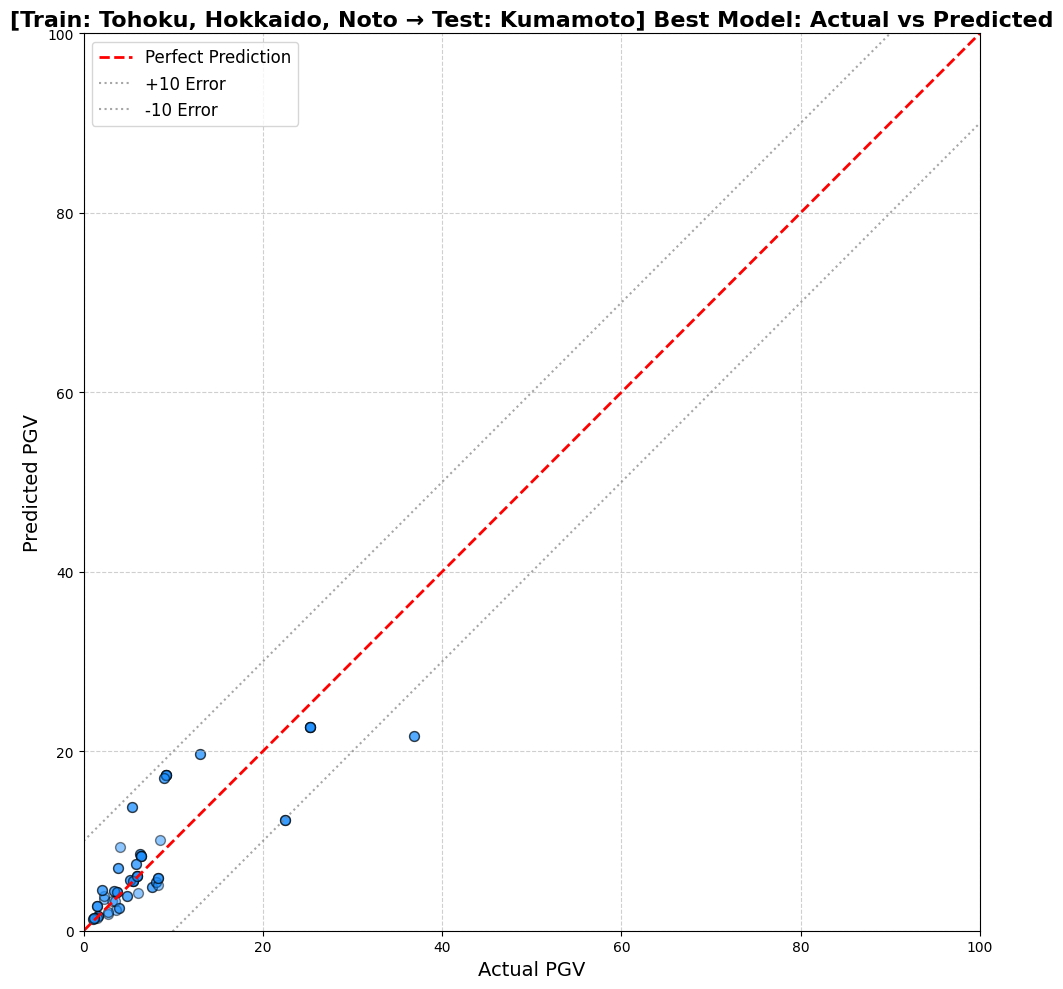

In [13]:
if __name__ == '__main__':
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print("=== Vs30 Lookup 빌드 ===")
    vs30_lookup = build_vs30_lookup_integrated(META_CSV, VS30_SHP)

    print("\n===== [실험 3] Train: Tohoku, Hokkaido, Noto / Test: Kumamoto ====\n")
    best_model_2k, metric_2k, test_loader_2k = main(test_event="kumamoto")

    summarize(metric_2k, "Train: Tohoku, Hokkaido, Noto -> Test: Kumamoto")

    plot_best_model_predictions(best_model_2k, test_loader_2k, device, "Train: Tohoku, Hokkaido, Noto → Test: Kumamoto",
                                y_mean=metric_2k['y_mean'], y_std=metric_2k['y_std'])

# [실험 4] Train: Kumamoto, Hokkaido, Noto / Test: Tohoku

=== Vs30 Lookup 빌드 ===
[Vs30] 통합 lookup: 280개 관측소 | fallback=0.9533 | log_amp μ=-0.0317 σ=0.2825

===== [실험 4] Train: Kumamoto, Hokkaido, Noto / Test: Tohoku ====

Device: cuda
[Combined Stats] train_events=['noto', 'hokkaido', 'kumamoto'] | y_mean=1.554455, y_std=0.846771 (n=398)
[Dataset] events=['noto', 'hokkaido', 'kumamoto'] | 유효 샘플: 398
[Dataset] events=['tohoku'] | 유효 샘플: 172
>> Train: tohoku 제외 나머지 세 지진 / Val+Test: tohoku
============================== Train ==============================


/tmp/ipykernel_963/2299933679.py:32: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()
/tmp/ipykernel_963/2299933679.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/100] LR: 0.000120 | Train: 0.6450 | Val: 1.5464 (RMSE: 24.80)


/tmp/ipykernel_963/2299933679.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [2/100] LR: 0.000180 | Train: 0.5664 | Val: 1.2643 (RMSE: 24.00)
Epoch [3/100] LR: 0.000240 | Train: 0.4156 | Val: 2.5841 (RMSE: 25.61)
Epoch [4/100] LR: 0.000300 | Train: 0.4453 | Val: 1.2495 (RMSE: 23.48)
Epoch [5/100] LR: 0.000300 | Train: 0.4652 | Val: 2.2342 (RMSE: 25.82)
Epoch [6/100] LR: 0.000300 | Train: 0.4044 | Val: 2.5225 (RMSE: 25.62)
Epoch [7/100] LR: 0.000300 | Train: 0.3577 | Val: 2.8983 (RMSE: 26.35)
Epoch [8/100] LR: 0.000299 | Train: 0.3655 | Val: 1.3569 (RMSE: 23.43)
Epoch [9/100] LR: 0.000299 | Train: 0.3663 | Val: 0.8974 (RMSE: 21.56)
Epoch [10/100] LR: 0.000298 | Train: 0.3308 | Val: 0.7925 (RMSE: 21.18)
Epoch [11/100] LR: 0.000297 | Train: 0.3519 | Val: 2.2357 (RMSE: 25.12)
Epoch [12/100] LR: 0.000296 | Train: 0.2724 | Val: 0.7925 (RMSE: 21.22)
Epoch [13/100] LR: 0.000295 | Train: 0.3070 | Val: 1.0212 (RMSE: 22.09)
Epoch [14/100] LR: 0.000294 | Train: 0.2265 | Val: 1.6974 (RMSE: 23.58)
Epoch [15/100] LR: 0.000292 | Train: 0.2780 | Val: 1.3494 (RMSE: 21.88)


/tmp/ipykernel_963/2299933679.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Final Test Loss: 5.2064 | Test RMSE: 12.27

[Train: Kumamoto, Hokkaido, Noto -> Test: Tohoku] 학습 결과 요약
  Best Val RMSE    : 15.47  (Epoch 31)
  Val Loss 스파이크: 0회
  최종 Train Loss  : 0.1342
  최종 Val Loss    : 0.7083
--------------------------------------------------------------------
  최종 Test Loss   : 0.5785
  최종 Test RMSE   : 12.27


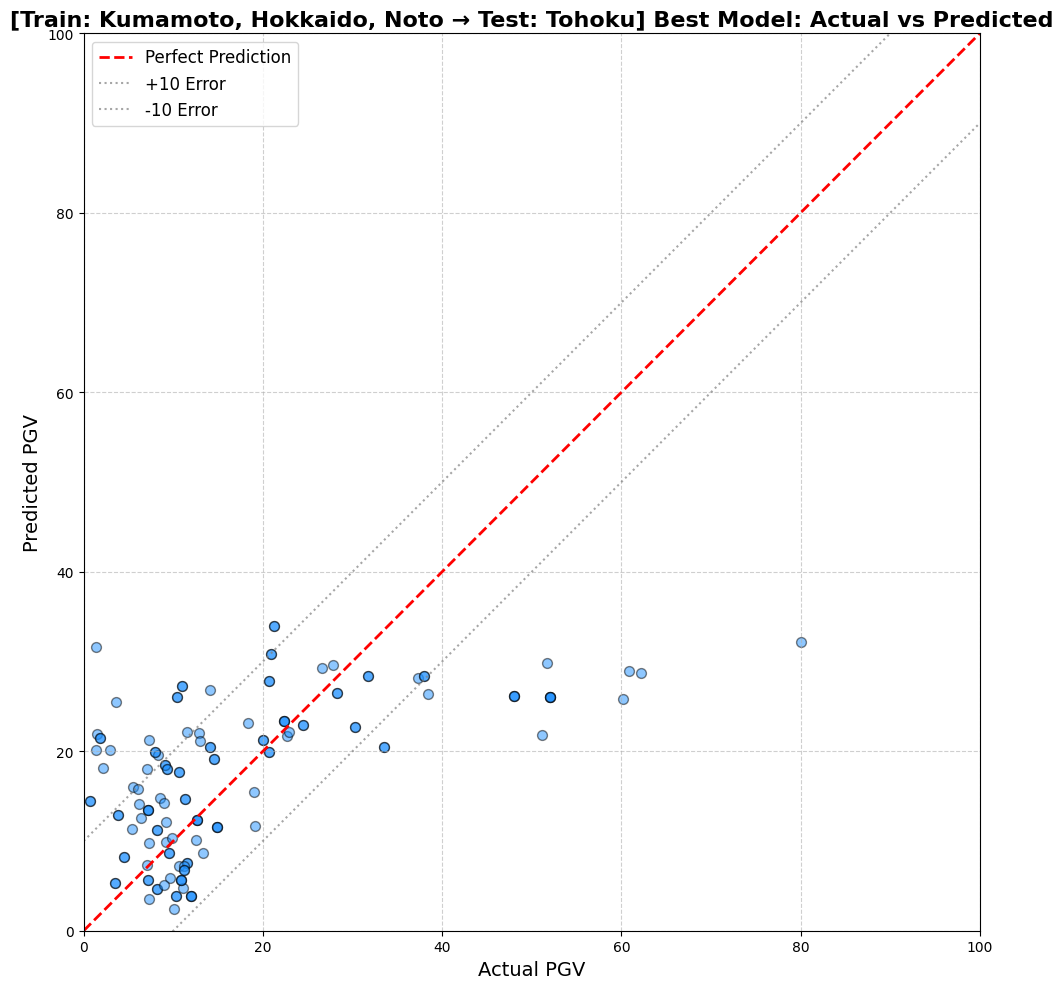

In [14]:
if __name__ == '__main__':
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print("=== Vs30 Lookup 빌드 ===")
    vs30_lookup = build_vs30_lookup_integrated(META_CSV, VS30_SHP)

    print("\n===== [실험 4] Train: Kumamoto, Hokkaido, Noto / Test: Tohoku ====\n")
    best_model_2t, metric_2t, test_loader_2t = main(test_event="tohoku")

    summarize(metric_2t, "Train: Kumamoto, Hokkaido, Noto -> Test: Tohoku")

    plot_best_model_predictions(best_model_2t, test_loader_2t, device, "Train: Kumamoto, Hokkaido, Noto → Test: Tohoku",
                                y_mean=metric_2t['y_mean'], y_std=metric_2t['y_std'])